**EXPERIMENT ONE**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 1: 0.2088 MB
Global model accuracy after round 1: 0.3343
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 2: 0.2088 MB
Global model accuracy after round 2: 0.2365
Round 3/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 3: 0.2088 MB
Global model accuracy after round 3: 0.2149
Round 4/30
Training on client 1
Training on client 2
Training on

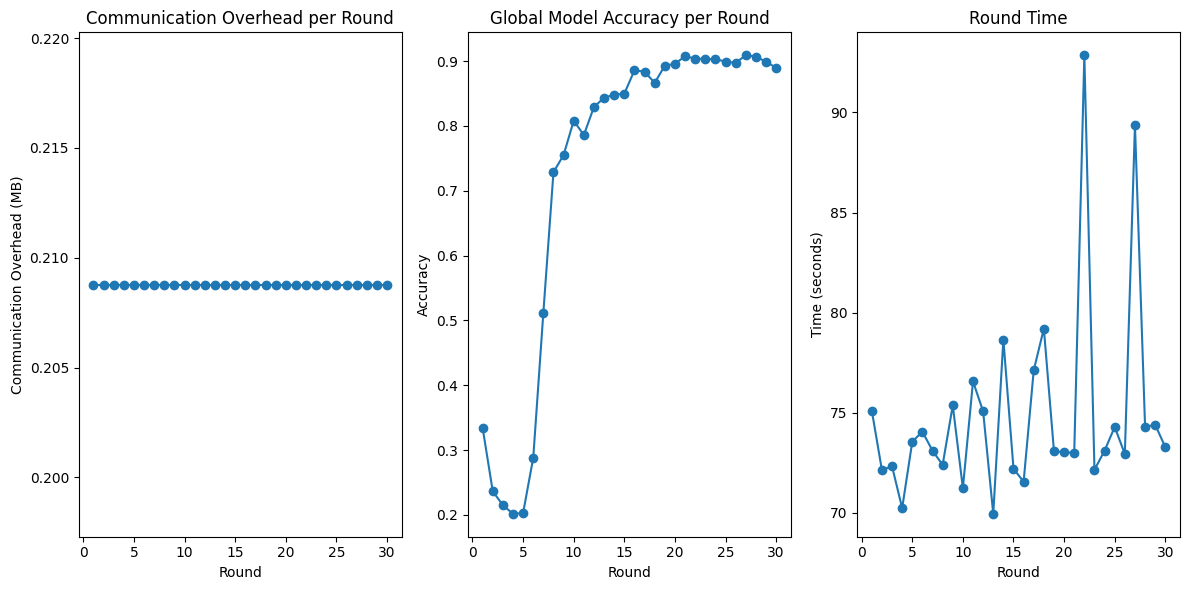

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Loading and preprocessing the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Converting dataframe to numpy array
    data = df.to_numpy()

    # Normalizing the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Splitting into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Converting continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Splitting into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Loading and preprocessing data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=10):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=10)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 10
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT TWO**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Communication overhead for round 1: 0.2088 MB
Global model accuracy after round 1: 0.3343
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Communication overhead for

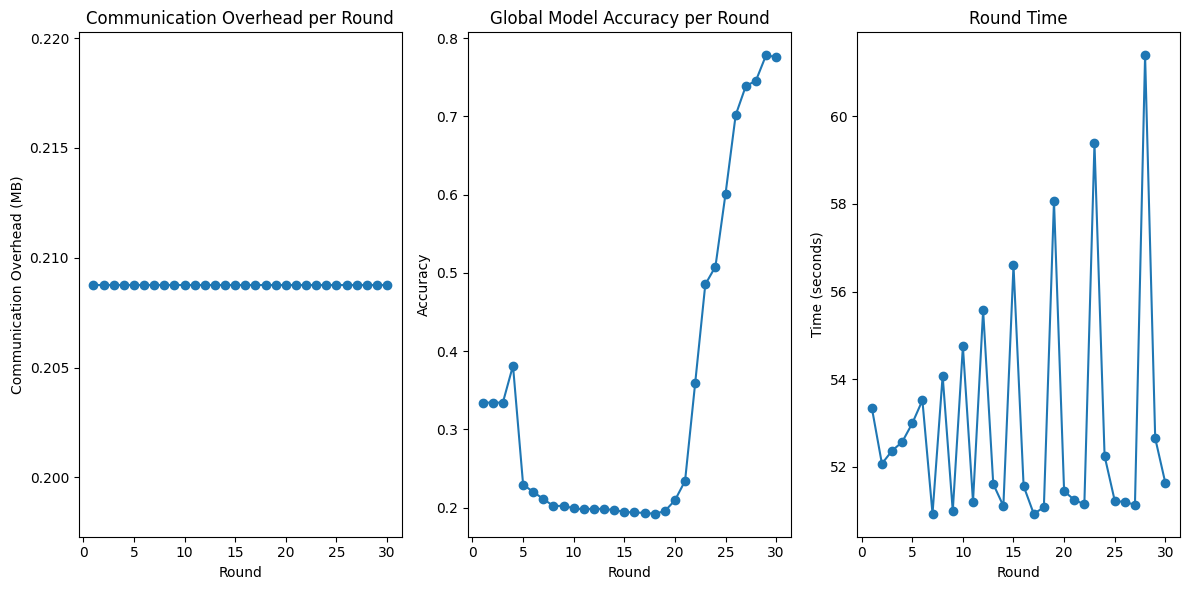

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=20):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=20)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 20
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT THREE**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Communication overhead for round 1: 0.2088 MB
Global model accuracy after round 1: 0.3343
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Trai

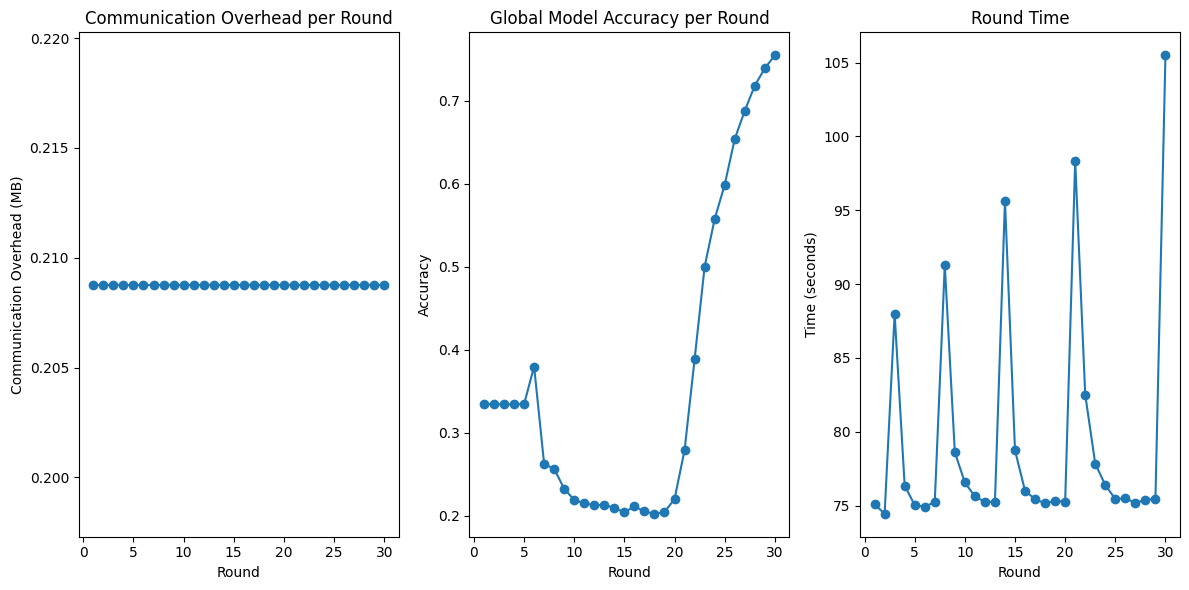

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=30):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=30)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 30
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FOUR**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Communication overhead for round 1: 0.2088 MB
Global model accuracy after round 1: 0.3343
Round 2/30
Training on clien

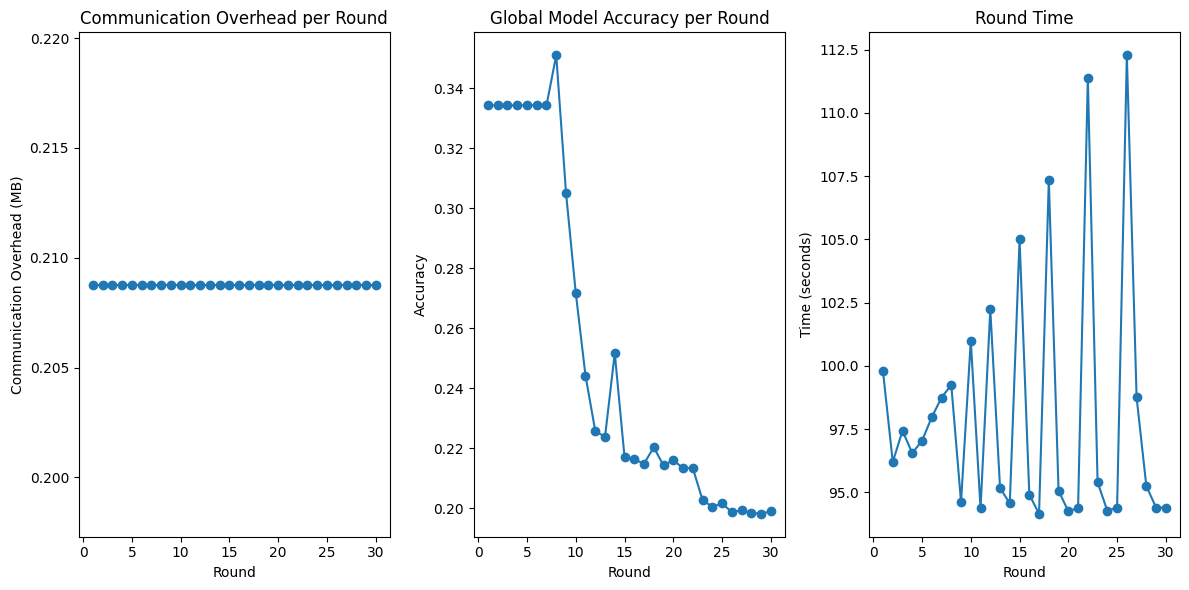

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=40):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=40)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 40
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FIVE**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

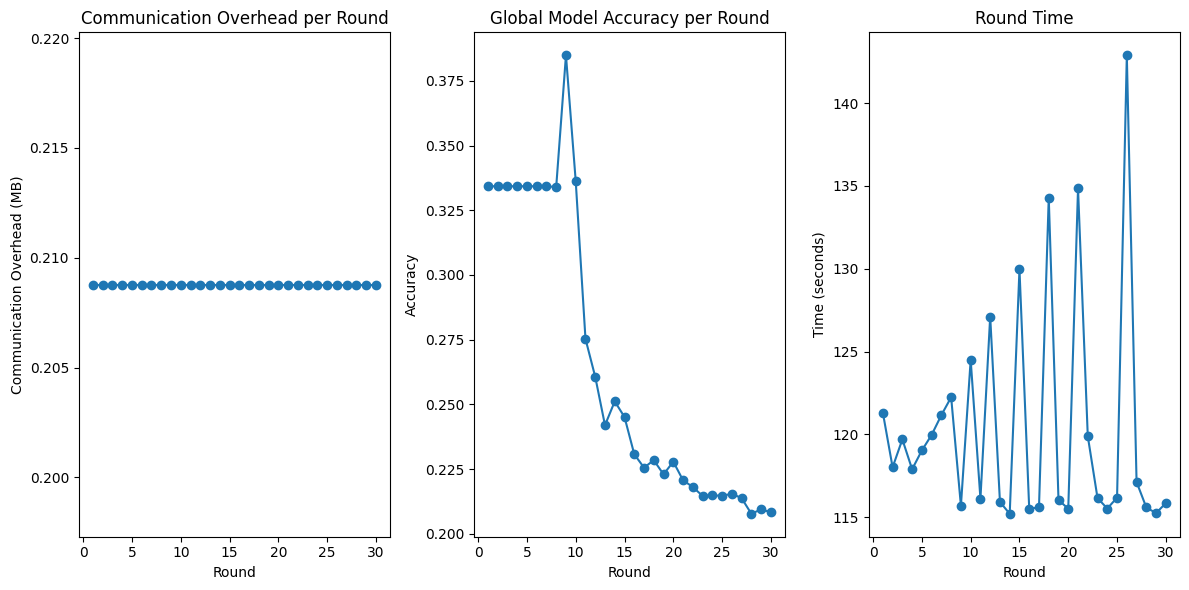

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=50):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=50)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 50
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT SIX**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

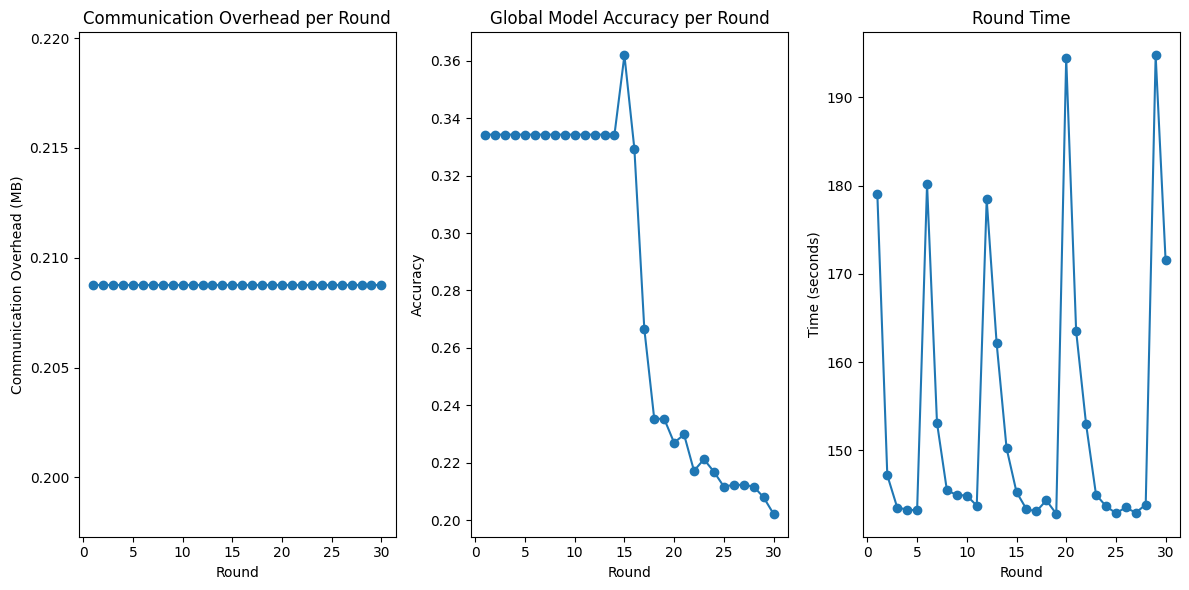

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=60):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=60)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 60
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT SEVEN**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

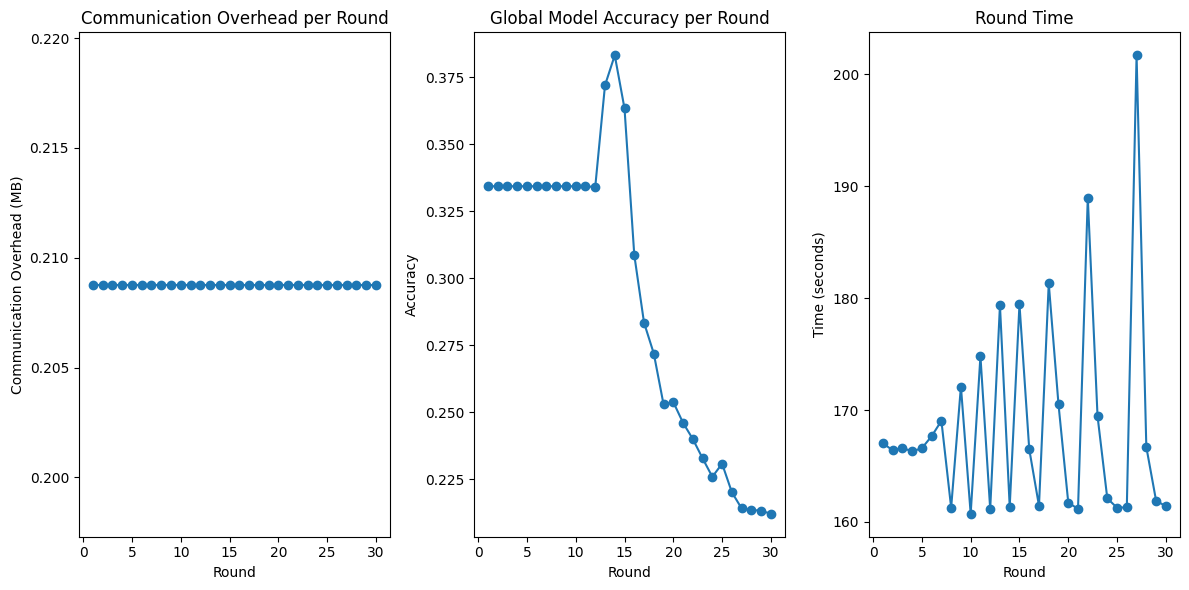

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=70):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=70)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 70
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT EIGHT**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

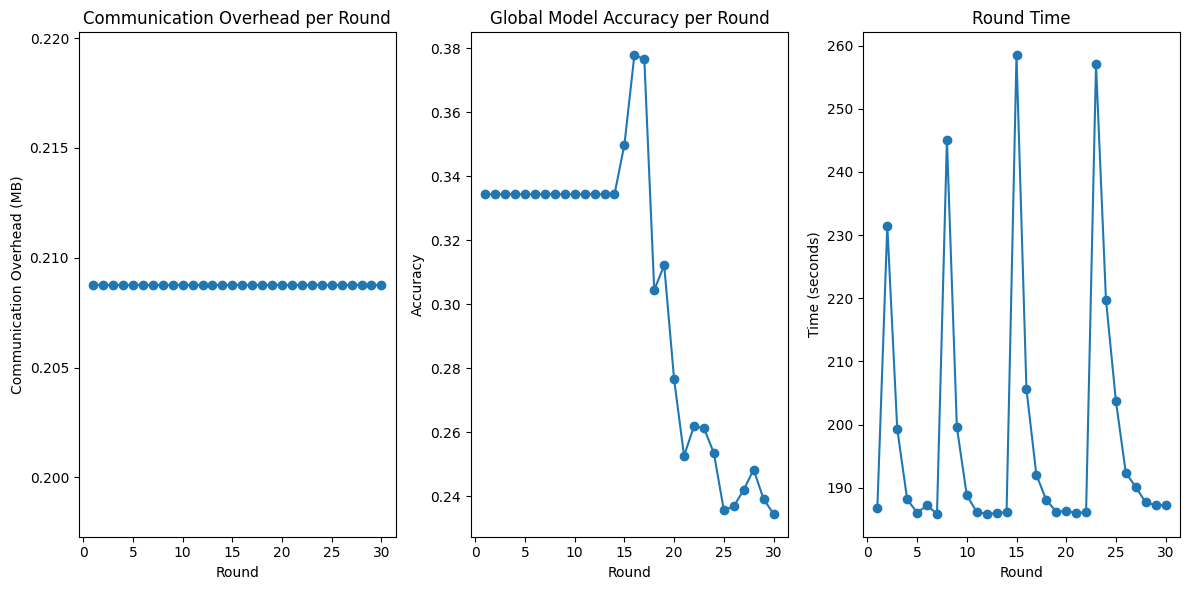

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=80):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=80)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 80
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT NINE**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

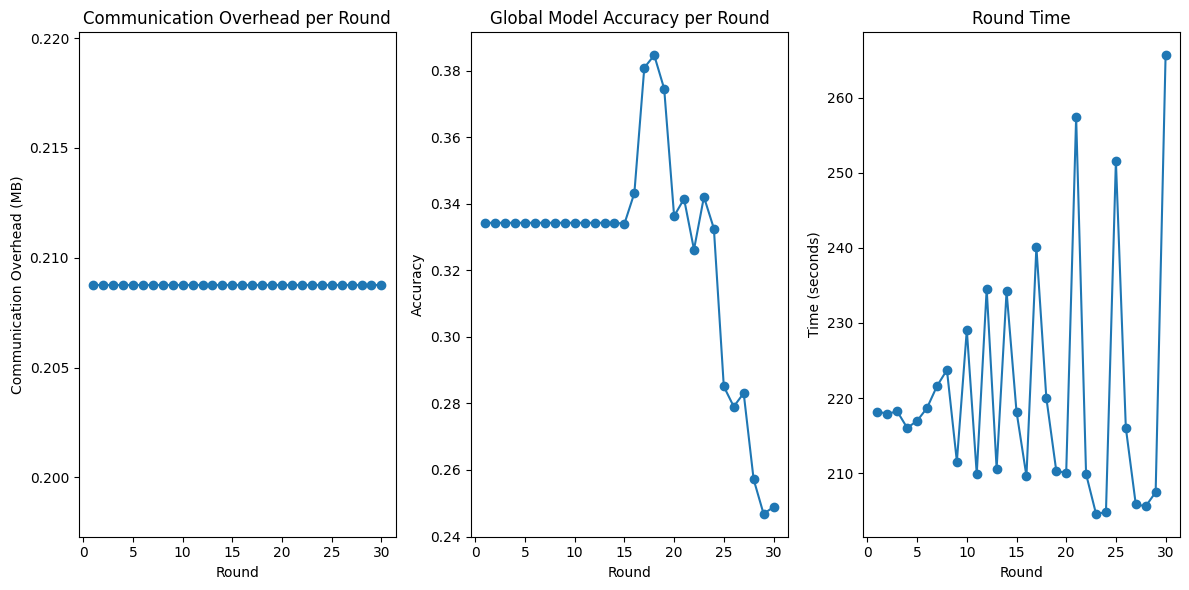

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=90):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=90)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 90
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 584.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.7 MB/s eta 0:00:00


**EXPERIMENT TEN**

Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 39
Training on client 40
Training on client 41
Training on client 42
Training on client 43
Training on client 44
Training on client 45
Training

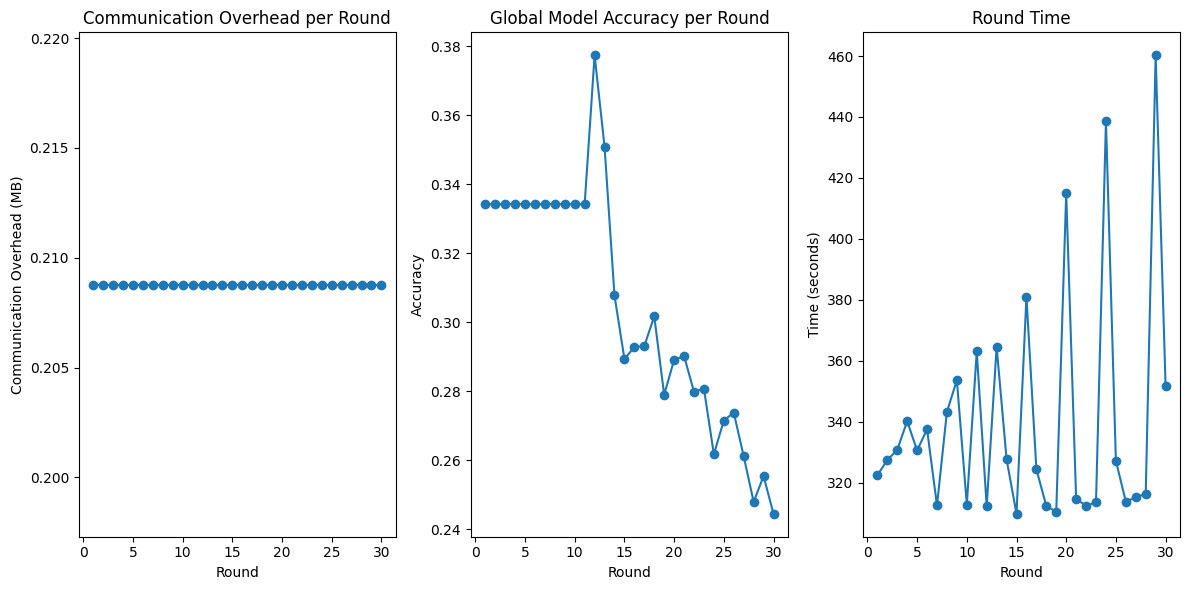

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(x, y, num_clients=100):
    client_data = []
    data_per_client = len(x) // num_clients
    for i in range(num_clients):
        client_x = x[i * data_per_client:(i + 1) * data_per_client]
        client_y = y[i * data_per_client:(i + 1) * data_per_client]
        client_data.append((client_x, client_y))
    return client_data

# Create federated data for each client
federated_train_data = create_federated_data(x_train, y_train, num_clients=100)

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 100
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Create global model
input_shape = (x_train.shape[1], 1)
global_model = create_rnn_model(input_shape, num_classes)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_rnn_model(input_shape, num_classes)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        X, y = federated_train_data[client_id]

        # Reshape data for LSTM input
        X = X.reshape((X.shape[0], X.shape[1], 1))

        # Train local model
        local_model.fit(X, y, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
    loss, accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
X_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
final_loss, final_accuracy = global_model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**CENTRALIZED EXPERIMENT**

Epoch 1/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4484 - loss: 1.5848 - val_accuracy: 0.2169 - val_loss: 1.8260
Epoch 2/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5021 - loss: 1.2583 - val_accuracy: 0.8015 - val_loss: 0.7986
Epoch 3/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8453 - loss: 0.4526 - val_accuracy: 0.8262 - val_loss: 0.5224
Epoch 4/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9065 - loss: 0.2771 - val_accuracy: 0.8720 - val_loss: 0.4063
Epoch 5/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9250 - loss: 0.2148 - val_accuracy: 0.8820 - val_loss: 0.3385
Epoch 6/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9413 - loss: 0.1728 - val_accuracy: 0.8795 - val_loss: 0.2915
Epoch 7/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9420 - loss: 0.1509 - val_accuracy: 0.8898 - val_loss: 0.2663
Epoch 8/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9496 - loss: 0.1389 - val_accu

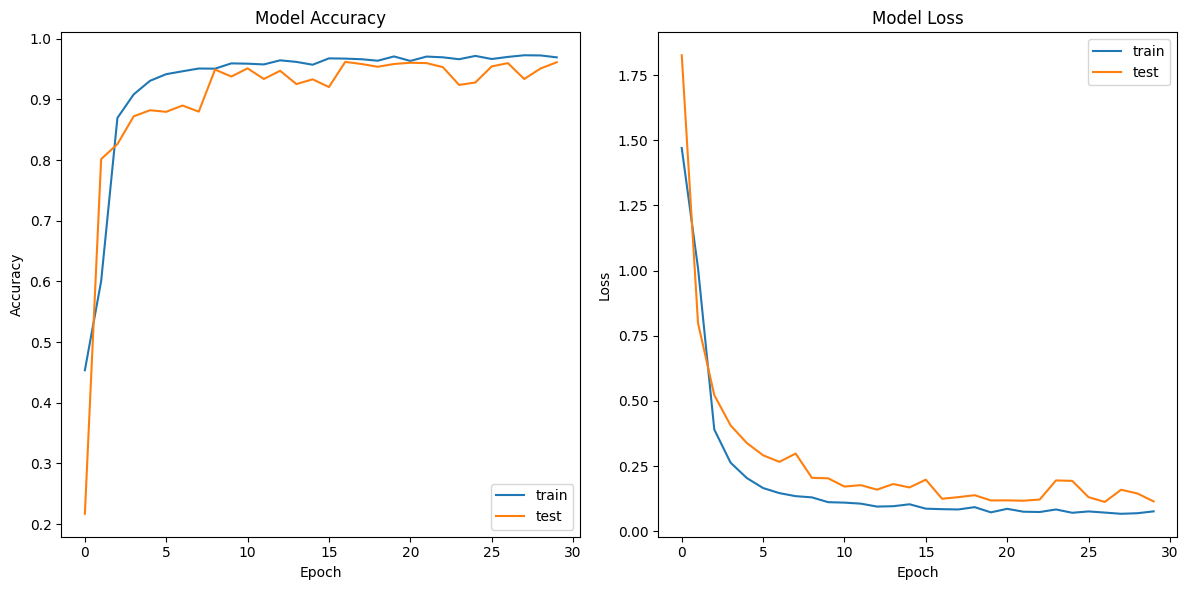

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import time
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from zipfile import ZipFile
import requests

# Load and preprocess the Bike Sharing dataset
def load_and_preprocess_data():
    # Load the dataset
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    response = requests.get(url)
    with ZipFile(BytesIO(response.content)) as thezip:
        with thezip.open('hour.csv') as thefile:
            df = pd.read_csv(thefile, header=0, sep=',', quotechar='"', usecols=range(2, 17))

    # Convert dataframe to numpy array
    data = df.to_numpy()

    # Normalize the data
    scaler = MinMaxScaler()
    data = scaler.fit_transform(data)

    # Split into features and labels
    X = data[:, :-1]  # All columns except the last one
    y = data[:, -1]   # The last column (count)

    # Convert continuous labels to discrete classes
    y = np.digitize(y, bins=np.linspace(0, 1, num=10)) - 1  # 10 classes

    # Split into train and test sets
    split_idx = int(0.8 * len(X))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return (X_train, y_train), (X_test, y_test), 10  # 10 classes

# Load and preprocess data
(x_train, y_train), (x_test, y_test), num_classes = load_and_preprocess_data()

# Define the global RNN model
def create_rnn_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile the model
input_shape = (x_train.shape[1], 1)
model = create_rnn_model(input_shape, num_classes)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Reshape data for LSTM input
x_train_reshaped = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test_reshaped = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# Train the model
start_time = time.time()
history = model.fit(x_train_reshaped, y_train, epochs=30, batch_size=32, validation_data=(x_test_reshaped, y_test), verbose=1)
training_time = time.time() - start_time

# Evaluate the model
final_loss, final_accuracy = model.evaluate(x_test_reshaped, y_test, verbose=0)
print(f"Final model accuracy: {final_accuracy:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Visualization
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()